# Donor Upgrade Potential

This notebook is one of the required IS 455 machine learning pipelines for the INTEX project. It is written to be executable top to bottom and to tell the complete story from business framing through deployment notes.


In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

repo_root = Path.cwd()
pipeline_dir = repo_root / "ml-pipelines"
if not pipeline_dir.exists() and repo_root.name == "ml-pipelines":
    pipeline_dir = repo_root
    repo_root = repo_root.parent
if str(pipeline_dir) not in sys.path:
    sys.path.insert(0, str(pipeline_dir))

import common_utils as cu

plt.style.use("ggplot")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


# 1. Problem Framing

**Business problem.** Which supporters are most likely to increase giving or make a larger next donation if asked?

**Who cares.** Fundraising staff, development leadership, and the admin team managing the Donations tab care about this because it shapes who receives personalized outreach and recommended ask amounts.

**Why it matters to the website and the case.** This pipeline supports the deployed Bella Porto Foundation experience by turning raw data into decisions that staff or donors can actually use in the application. That aligns with the IS 455 rubric, which requires complete pipeline thinking rather than an algorithm in isolation.

**Predictive vs explanatory framing.** This notebook is explicitly **both**, and it includes both an explanatory model and a predictive model because those solve different decisions.

This notebook intentionally includes both an explanatory model and a predictive model. The explanatory logistic model helps staff understand which donor behaviors travel with upgrade behavior, while the predictive regressor is tuned for operational ranking of likely major-gift or upgrade candidates.

**Target definition.** The explanatory target is `upgrade_flag`, defined at the donor-event level as whether the next donation exceeds 110% of the donor's historical median gift. The predictive target is `next_donation_amount`, the value of the next donation in the donor timeline.


In [2]:
bundle = cu.prepare_donor_upgrade_dataset()
df = bundle["data"].copy()
feature_cols = bundle["feature_cols"]
numeric_cols = bundle["numeric_cols"]
categorical_cols = bundle["categorical_cols"]

print("Dataset shape:", df.shape)
print("Feature columns:", len(feature_cols))
print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))
display(df.head())

for label, target in [("Explanatory target", bundle["explanatory_target"]), ("Predictive target", bundle["predictive_target"])]:
    if target in df.columns:
        print(f"\n{label}: {target}")
        display(df[target].describe(include="all"))


Dataset shape: (361, 37)
Feature columns: 24
Numeric columns: 15
Categorical columns: 9


,donation_id,supporter_id,donation_type,donation_date,is_recurring,campaign_name,channel_source,currency_code,amount,estimated_value,impact_unit,notes,referral_post_id,donation_value,donation_allocation_total,donation_program_area_count,engagement_rate,click_throughs,donation_referrals,donation_number,days_since_prev,hist_value_sum,hist_value_mean,hist_value_median,hist_value_max,hist_recurring_share,hist_social_referral_share,hist_campaign_diversity,hist_channel_diversity,next_donation_amount,upgrade_flag,supporter_type,relationship_type,region,country,status,acquisition_channel
0,145,1,Monetary,2023-03-25,True,NaN,SocialMedia,PHP,774.61,774.61,pesos,In support of safehouse operations,70.0,774.61,774.62,2,0.0426,261.0,19.0,1,NaN,774.61,774.610,774.610,774.61,1.0,1.000000,1,1,606.91,0,SocialMediaAdvocate,Local,Luzon,Philippines,Active,SocialMedia
1,158,1,InKind,2023-06-24,True,Back to School,Direct,NaN,NaN,606.91,items,Recurring gift,NaN,606.91,606.90,2,NaN,NaN,NaN,2,91.0,1381.52,690.760,690.760,774.61,1.0,0.500000,2,2,663.94,0,SocialMediaAdvocate,Local,Luzon,Philippines,Active,SocialMedia
2,295,1,Monetary,2023-07-01,True,NaN,Event,PHP,663.94,663.94,pesos,Community outreach support,NaN,663.94,663.94,1,NaN,NaN,NaN,3,7.0,2045.46,681.820,663.940,774.61,1.0,0.333333,2,3,300.00,0,SocialMediaAdvocate,Local,Luzon,Philippines,Active,SocialMedia
3,15,1,InKind,2023-07-02,True,NaN,Event,NaN,NaN,300.00,items,Campaign support,NaN,300.00,300.00,2,NaN,NaN,NaN,4,1.0,2345.46,586.365,635.425,774.61,1.0,0.250000,2,3,19.20,0,SocialMediaAdvocate,Local,Luzon,Philippines,Active,SocialMedia
4,148,1,Time,2023-07-23,True,NaN,SocialMedia,NaN,NaN,19.20,hours,Community outreach support,457.0,19.20,19.20,1,0.0676,120.0,17.0,5,21.0,2364.66,472.932,606.910,774.61,1.0,0.400000,2,3,2628.14,1,SocialMediaAdvocate,Local,Luzon,Philippines,Active,SocialMedia



Explanatory target: upgrade_flag


count    361.000000
mean       0.493075
std        0.500646
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: upgrade_flag, dtype: float64


Predictive target: next_donation_amount


count     361.000000
mean      726.553601
std       729.331241
min         2.200000
25%       300.000000
50%       537.370000
75%      1014.670000
max      6481.540000
Name: next_donation_amount, dtype: float64

**Executive Takeaway.** The problem is framed as a real operating decision, not just a modeling exercise. The explanatory model helps the team reason about relationships, while the predictive model is reserved for scoring, ranking, or forecasting inside the website.


# 2. Data Acquisition, Preparation & Exploration

**Relevant tables and join logic.** `supporters`, `donations`, `donation_allocations`, and `social_media_posts` are combined to capture donor profile, giving cadence, allocation behavior, and referral-post context.

The preparation code below uses reusable pandas transformations and scikit-learn-compatible feature sets rather than one-off ad hoc cleaning. Missing values are handled explicitly by the modeling pipelines, while date parsing, aggregation grain, and proxy target construction are all documented in code.


,column,missing_share
0,click_throughs,0.817175
1,donation_referrals,0.817175
2,engagement_rate,0.817175
3,campaign_name,0.645429
4,days_since_prev,0.160665
5,upgrade_flag,0.000000
6,acquisition_channel,0.000000
7,status,0.000000
8,country,0.000000
9,region,0.000000


,donation_number,days_since_prev,hist_value_sum,hist_value_mean,hist_value_median,hist_value_max,next_donation_amount
donation_number,1.000,-0.264,0.905,0.114,0.059,0.423,-0.025
days_since_prev,-0.264,1.000,-0.255,-0.101,-0.114,-0.107,0.016
hist_value_sum,0.905,-0.255,1.000,0.424,0.302,0.692,-0.012
hist_value_mean,0.114,-0.101,0.424,1.000,0.873,0.753,-0.006
hist_value_median,0.059,-0.114,0.302,0.873,1.000,0.440,-0.084
hist_value_max,0.423,-0.107,0.692,0.753,0.440,1.000,0.077
next_donation_amount,-0.025,0.016,-0.012,-0.006,-0.084,0.077,1.000


Top categories for donation_type:


,donation_type,count
0,Monetary,201
1,InKind,84
2,Time,38
3,SocialMedia,22
4,Skills,16


,feature,p01,median,p99
0,donation_number,1.000,4.00,19.000
1,days_since_prev,1.000,70.00,590.900
2,hist_value_sum,4.834,2353.68,11183.432
3,hist_value_mean,4.834,610.82,1836.326
4,hist_value_median,4.834,525.32,1676.182
5,hist_value_max,4.834,1177.41,4101.536


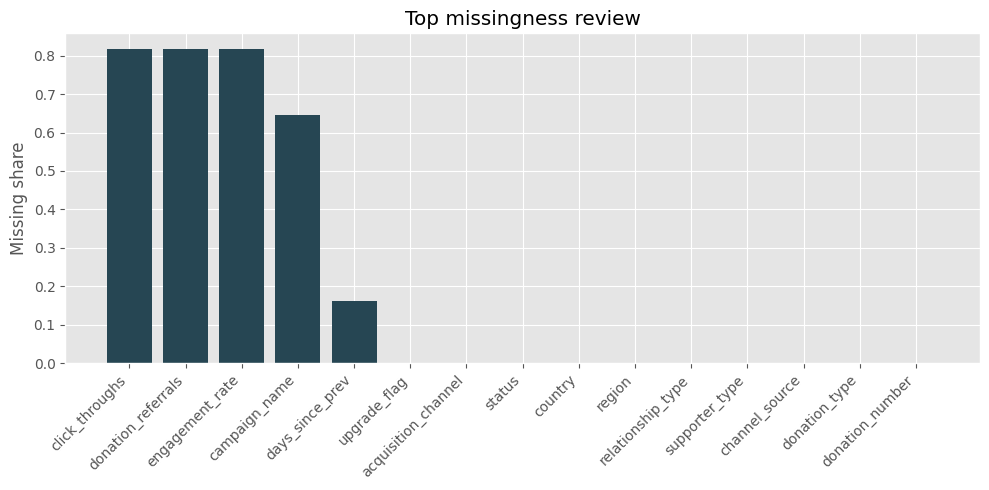

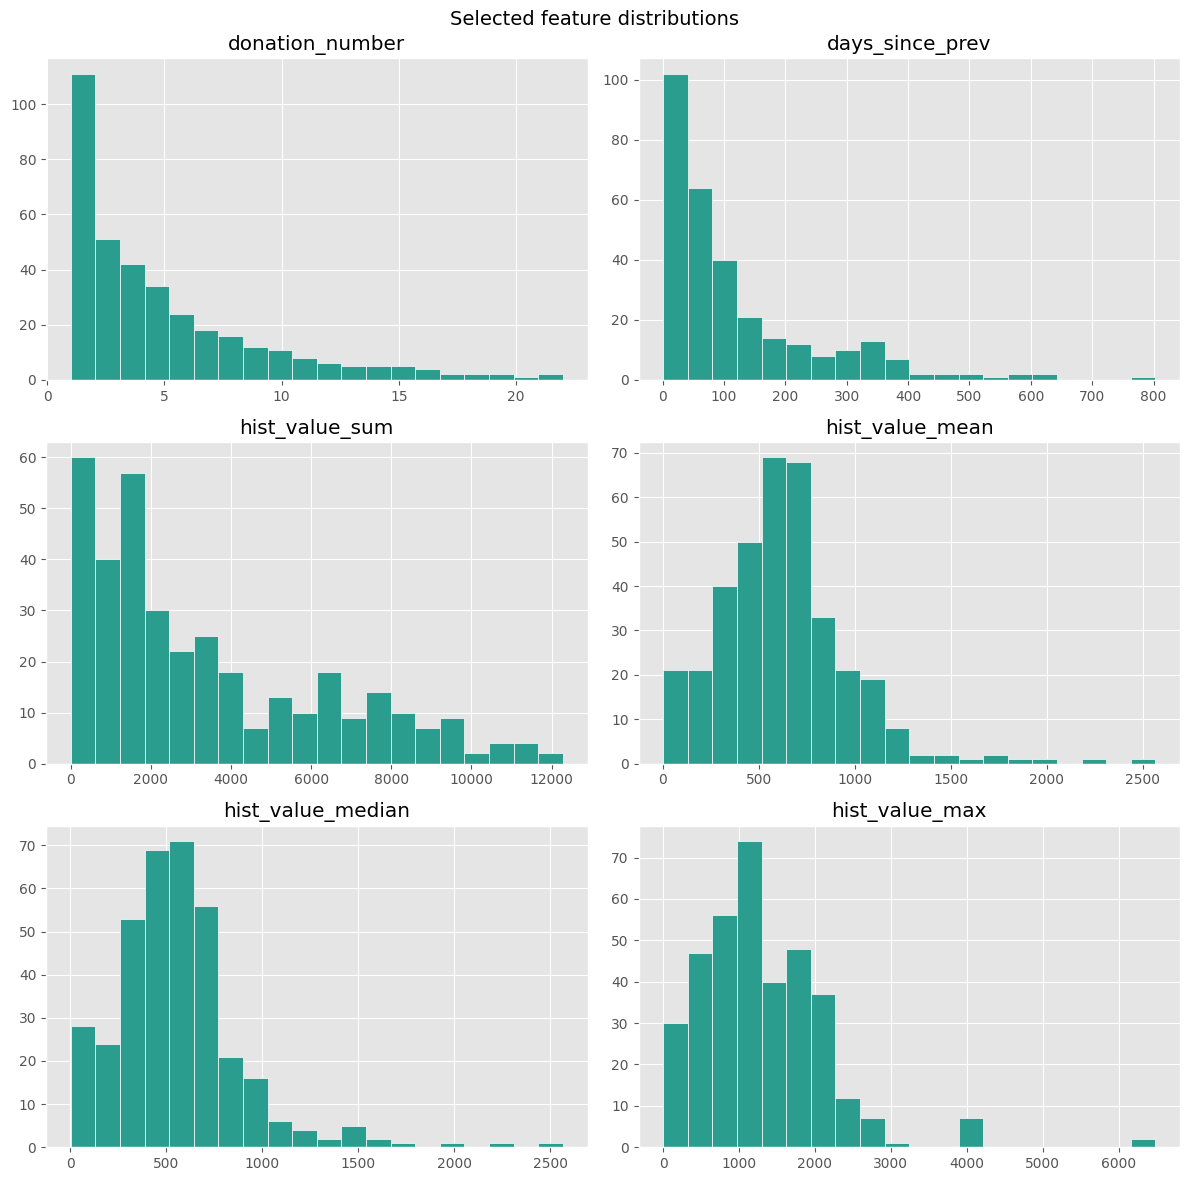

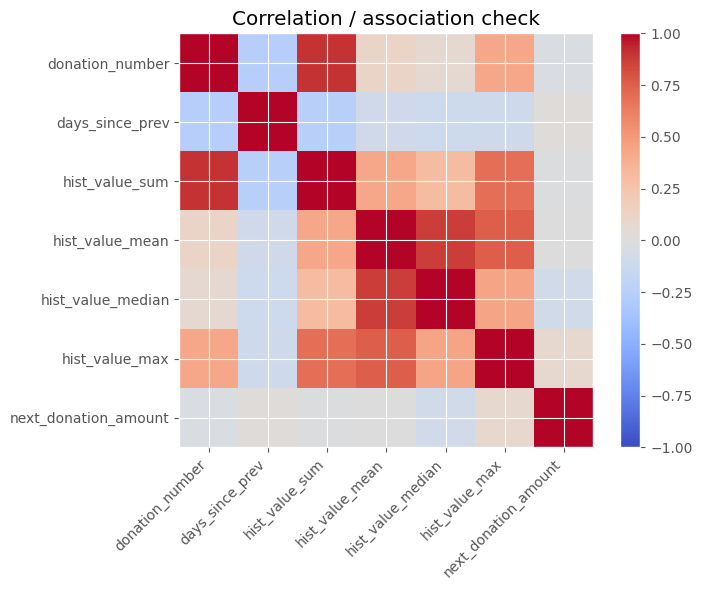

In [3]:
missing_table = cu.plot_missingness(df[feature_cols + [bundle["explanatory_target"], bundle["predictive_target"]]].copy(), "Top missingness review")
display(missing_table)

preview_numeric = [
    col
    for col in numeric_cols
    if col in df.columns and not pd.api.types.is_bool_dtype(df[col])
][:6]
if preview_numeric:
    cu.plot_numeric_overview(df, preview_numeric, "Selected feature distributions")

corr_candidates = [
    col
    for col in preview_numeric
    if pd.api.types.is_numeric_dtype(df[col]) and not pd.api.types.is_bool_dtype(df[col])
]
if bundle["predictive_target"] in df.columns and pd.api.types.is_numeric_dtype(df[bundle["predictive_target"]]):
    corr_candidates = corr_candidates + [bundle["predictive_target"]]
elif bundle["explanatory_target"] in df.columns and pd.api.types.is_numeric_dtype(df[bundle["explanatory_target"]]):
    corr_candidates = corr_candidates + [bundle["explanatory_target"]]

corr_candidates = list(dict.fromkeys([col for col in corr_candidates if col in df.columns]))
if len(corr_candidates) >= 3:
    corr = cu.plot_correlation_heatmap(df, corr_candidates, "Correlation / association check")
    display(corr.round(3))

if categorical_cols:
    cat = categorical_cols[0]
    print(f"Top categories for {cat}:")
    display(
        df[cat]
        .fillna("Missing")
        .value_counts()
        .head(10)
        .rename("count")
        .reset_index()
        .rename(columns={"index": cat})
    )

outlier_review = pd.DataFrame({
    "feature": preview_numeric,
    "p01": [pd.to_numeric(df[col], errors="coerce").quantile(0.01) for col in preview_numeric],
    "median": [pd.to_numeric(df[col], errors="coerce").median() for col in preview_numeric],
    "p99": [pd.to_numeric(df[col], errors="coerce").quantile(0.99) for col in preview_numeric],
})
display(outlier_review)


**Executive Takeaway.** The exploration stage verifies that the target and candidate drivers are measurable, identifies missingness patterns early, and checks whether the dataset grain matches the decision being modeled. Outliers are kept visible and interpreted, rather than silently discarded.


# 3. Modeling & Feature Selection

The feature set deliberately favors operationally available columns over every possible field in the raw tables. That matters for two reasons:

1. The website can only score records with fields it actually stores and can refresh.
2. IS 455 expects feature selection to be justified instead of treating the dataset as a dumping ground.

The explanatory model is chosen for interpretability. The predictive model is chosen for stronger out-of-sample performance and non-linear pattern capture where appropriate.


In [4]:
explanatory_results = cu.fit_and_evaluate_model(
    df=df,
    feature_cols=feature_cols,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    target_col=bundle["explanatory_target"],
    kind=bundle["explanatory_kind"],
    role="explanatory",
    time_col=bundle["time_col"],
)

predictive_results = cu.fit_and_evaluate_model(
    df=df,
    feature_cols=feature_cols,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    target_col=bundle["predictive_target"],
    kind=bundle["predictive_kind"],
    role="predictive",
    time_col=bundle["time_col"],
)

print("Explanatory model metrics")
display(explanatory_results["metrics"])
print("Predictive model metrics")
display(predictive_results["metrics"])

print("Top explanatory features")
display(explanatory_results["feature_table"])
print("Top predictive features")
display(predictive_results["feature_table"])


Explanatory model metrics


,test_roc_auc,test_precision,test_recall,test_f1,test_log_loss,cv_roc_auc_mean,cv_f1_mean,cv_precision_mean,cv_recall_mean
0,0.616132,0.586207,0.404762,0.478873,0.751036,0.726631,0.662057,0.660465,0.673611


Predictive model metrics


,test_rmse,test_mae,test_r2,cv_rmse_mean,cv_mae_mean,cv_r2_mean
0,767.960708,571.257425,0.046185,767.933523,539.970262,-0.143921


Top explanatory features


,feature,effect,abs_effect
0,num__hist_value_median,-1.625472,1.625472
1,num__hist_value_sum,-0.777986,0.777986
2,cat__channel_source_Direct,0.600647,0.600647
3,cat__acquisition_channel_SocialMedia,0.577166,0.577166
4,num__hist_value_max,0.548314,0.548314
5,cat__region_Visayas,0.540593,0.540593
6,cat__region_Luzon,-0.536805,0.536805
7,cat__donation_type_InKind,-0.532421,0.532421
8,cat__acquisition_channel_Church,-0.482556,0.482556
9,cat__relationship_type_International,0.466551,0.466551


Top predictive features


,feature,effect,abs_effect
0,num__hist_value_median,0.143174,0.143174
1,num__donation_allocation_total,0.120333,0.120333
2,num__hist_value_mean,0.101347,0.101347
3,num__days_since_prev,0.079986,0.079986
4,num__hist_value_sum,0.073383,0.073383
5,num__hist_social_referral_share,0.062296,0.062296
6,num__hist_value_max,0.056242,0.056242
7,num__hist_channel_diversity,0.028951,0.028951
8,num__donation_number,0.024646,0.024646
9,cat__acquisition_channel_SocialMedia,0.022262,0.022262


**Executive Takeaway.** Feature selection is anchored in business logic first and model diagnostics second. The explanatory model clarifies directional relationships, and the predictive model tests whether additional flexibility improves operational usefulness enough to justify lower interpretability.


# 4. Evaluation & Interpretation

Proper validation matters because this organization will act on the outputs. The notebook therefore uses train/test logic with cross-validation summaries rather than evaluating only on the full sample.

**Real-world error tradeoff.** False positives cost staff time and may lead to awkward asks. False negatives are more expensive strategically because they hide donors who could have deepened support.



Explanatory model holdout sample preview


,upgrade_flag,prediction,score,split
0,1,1,0.893287,test
1,0,0,0.001214,test
2,1,1,0.774176,test
3,0,0,0.100914,test
4,1,1,0.899406,test
5,0,0,0.236745,test
6,1,0,0.323005,test
7,1,0,0.383101,test
8,0,1,0.545104,test
9,0,1,0.870603,test


Explanatory model confusion matrix


,pred_0,pred_1
actual_0,37,12
actual_1,25,17



Predictive model holdout sample preview


,next_donation_amount,prediction,residual,split
0,413.82,691.340060,-277.520060,test
1,12.44,794.781524,-782.341524,test
2,447.50,558.946832,-111.446832,test
3,2.50,848.254593,-845.754593,test
4,3189.71,981.900207,2207.809793,test
5,250.00,798.581061,-548.581061,test
6,2499.74,1292.479286,1207.260714,test
7,1321.41,701.826831,619.583169,test
8,300.00,836.521941,-536.521941,test
9,7.08,761.245808,-754.165808,test


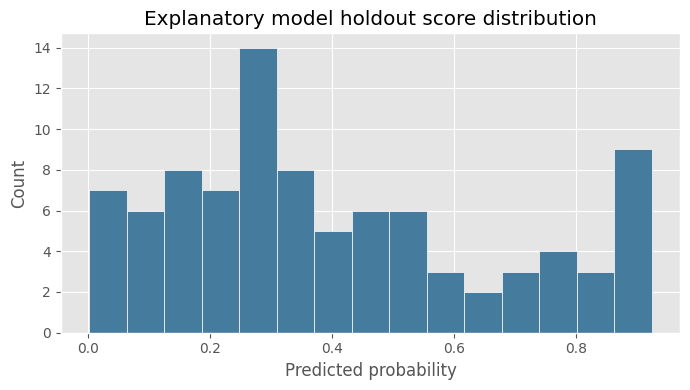

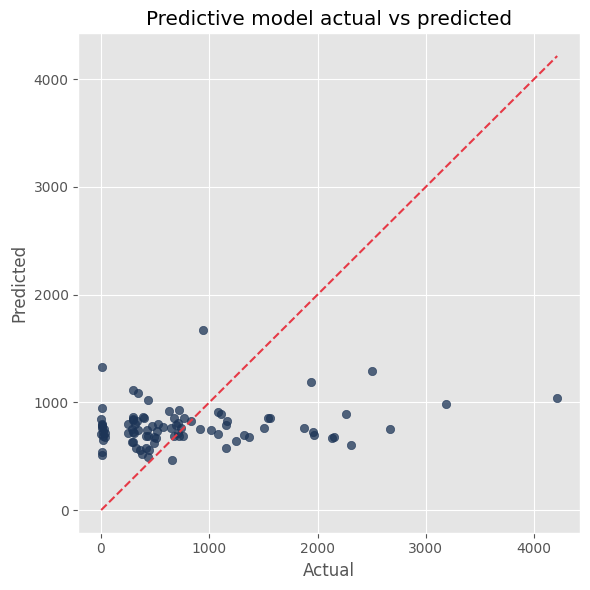

In [5]:
def show_model_diagnostics(label, results, kind, target_name):
    print(f"\n{label} holdout sample preview")
    display(results["holdout"].head(10))
    if kind == "classification":
        print(f"{label} confusion matrix")
        display(results["confusion_matrix"])
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.hist(results["holdout"]["score"], bins=15, color="#457b9d", edgecolor="white")
        ax.set_title(f"{label} holdout score distribution")
        ax.set_xlabel("Predicted probability")
        ax.set_ylabel("Count")
        plt.tight_layout()
    else:
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.scatter(results["holdout"][target_name], results["holdout"]["prediction"], alpha=0.75, color="#1d3557")
        lims = [
            np.nanmin([results["holdout"][target_name].min(), results["holdout"]["prediction"].min()]),
            np.nanmax([results["holdout"][target_name].max(), results["holdout"]["prediction"].max()]),
        ]
        ax.plot(lims, lims, linestyle="--", color="#e63946")
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.set_title(f"{label} actual vs predicted")
        plt.tight_layout()

show_model_diagnostics("Explanatory model", explanatory_results, bundle["explanatory_kind"], bundle["explanatory_target"])
show_model_diagnostics("Predictive model", predictive_results, bundle["predictive_kind"], bundle["predictive_target"])


**Executive Takeaway.** The evaluation section is intentionally honest. If the holdout performance is only moderate, that still has value as a prioritization aid as long as the notebook states the limitation clearly and keeps humans in the loop for high-stakes decisions.


# 5. Causal and Relationship Analysis

This section distinguishes what is **predictive** from what is plausibly **explanatory**.

Recency, cumulative giving, recurring history, and social referral patterns may be predictive without being causal. An enthusiastic donor may both engage more and give more because of an unobserved affinity to the mission.

The tables below focus on the strongest modeled relationships while being careful not to equate feature importance with proof of causality.


In [6]:
relationship_target = bundle["predictive_target"] if bundle["predictive_kind"] == "regression" else bundle["explanatory_target"]
relationship_numeric = [col for col in numeric_cols if col in df.columns and df[col].notna().sum() > 5][:12]

if relationship_target in df.columns and pd.api.types.is_numeric_dtype(df[relationship_target]) and relationship_numeric:
    relationship_table = (
        df[relationship_numeric + [relationship_target]]
        .apply(pd.to_numeric, errors="coerce")
        .corr(numeric_only=True)[[relationship_target]]
        .sort_values(relationship_target, ascending=False)
    )
    display(relationship_table.round(3))

explanatory_top = explanatory_results["feature_table"].copy()
predictive_top = predictive_results["feature_table"].copy()
explanatory_top["model"] = "explanatory"
predictive_top["model"] = "predictive"
combined_top = pd.concat([explanatory_top, predictive_top], ignore_index=True)
display(combined_top)


,next_donation_amount
next_donation_amount,1.000
hist_social_referral_share,0.105
donation_allocation_total,0.083
hist_value_max,0.077
hist_channel_diversity,0.066
hist_campaign_diversity,0.043
days_since_prev,0.016
hist_value_mean,-0.006
hist_value_sum,-0.012
donation_program_area_count,-0.014


,feature,effect,abs_effect,model
0,num__hist_value_median,-1.625472,1.625472,explanatory
1,num__hist_value_sum,-0.777986,0.777986,explanatory
2,cat__channel_source_Direct,0.600647,0.600647,explanatory
3,cat__acquisition_channel_SocialMedia,0.577166,0.577166,explanatory
4,num__hist_value_max,0.548314,0.548314,explanatory
5,cat__region_Visayas,0.540593,0.540593,explanatory
6,cat__region_Luzon,-0.536805,0.536805,explanatory
7,cat__donation_type_InKind,-0.532421,0.532421,explanatory
8,cat__acquisition_channel_Church,-0.482556,0.482556,explanatory
9,cat__relationship_type_International,0.466551,0.466551,explanatory


**Executive Takeaway.** The strongest drivers in the models are useful for strategy discussions, but they should be interpreted as structured evidence rather than causal proof. In this project, observational data is valuable for prioritization and learning even when it cannot support hard causal claims.


# 6. Deployment Notes

**Website integration path.** Use the outputs on `/admin?tab=donations` to power a "Top Upgrade Candidates" table, on `/admin` for a likely-major-gift KPI card, and on donor profile panels for expected next gift plus recommended ask size.

**Likely API surface.** A lightweight backend endpoint such as `/api/ml/donor-upgrade-score` can score new records or refresh dashboard aggregates on a schedule.

**Implementation sketch.**

```python
# pseudocode used by the web app or backend job
record_batch = load_latest_records_from_database()
scored = model.predict_or_predict_proba(record_batch)
write_scores_back_to_reporting_table(scored)
refresh_dashboard_cards()
```

**Repository alignment.** The current application already has pages for admin dashboard, donations, residents, reports, outreach, and impact, so this pipeline is designed to plug into those existing navigation surfaces instead of inventing a disconnected demo experience.


**Executive Takeaway.** A notebook-only model is not enough for the rubric. The practical endpoint of this work is a score, forecast, or explanatory summary that appears in the deployed web app where staff and donors can actually use it.
